In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import cv2

In [27]:
frame_id = 150
view_id = 2

path = "/synology/rajrup/VideoGS/HiFi4G_Dataset_processed"
sequence_names = os.listdir(path)

(2190, 4037, 3)
(2190, 4037, 3)
(2190, 4034, 3)
(2190, 4034, 3)
(2190, 4035, 3)
(2190, 4035, 3)
(2190, 4037, 3)


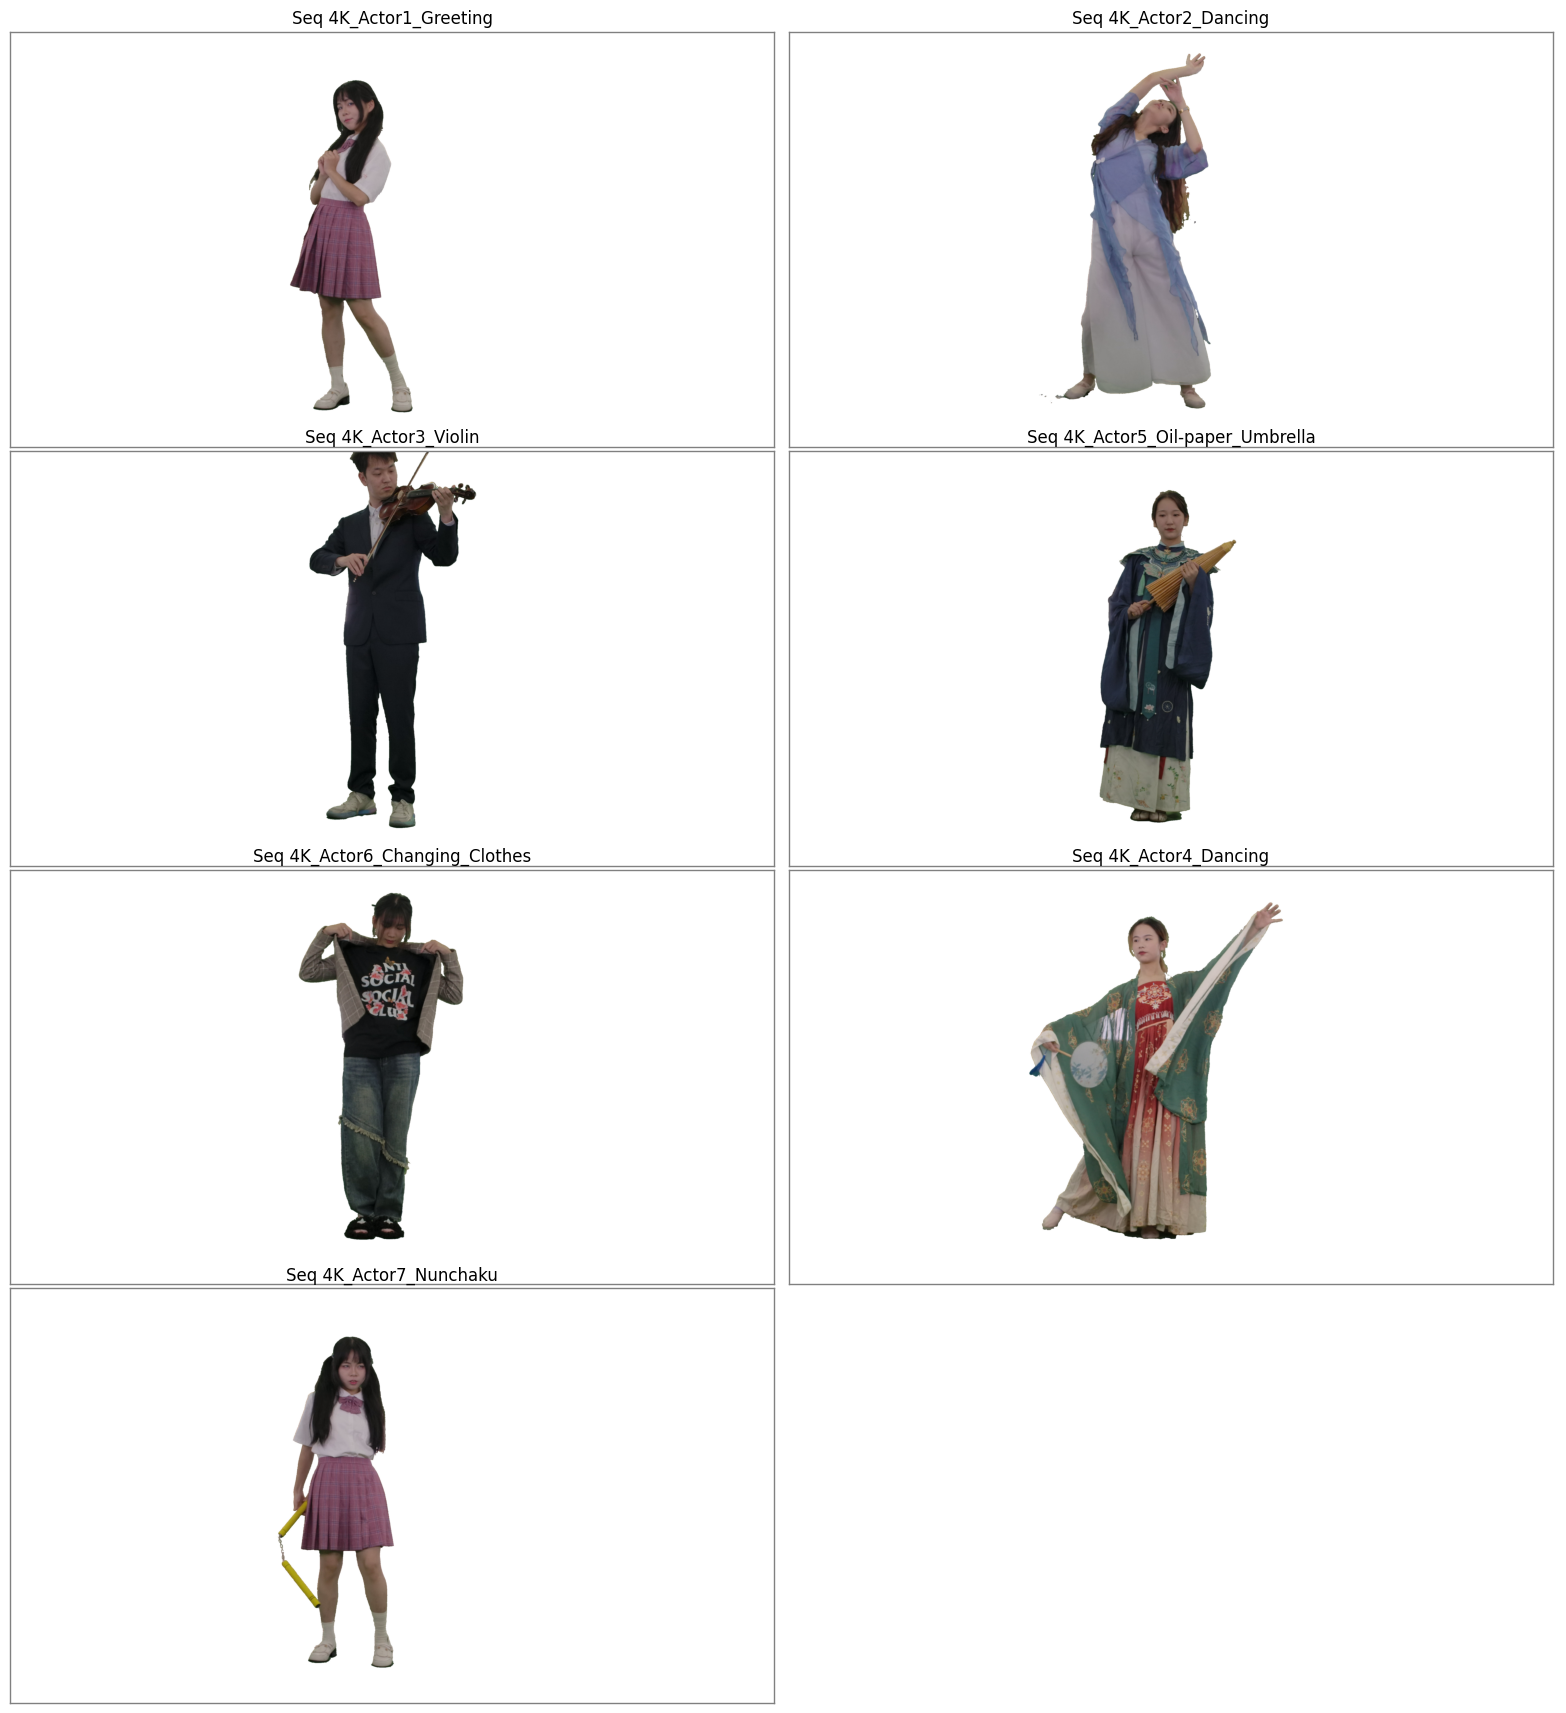

In [28]:
images = []
for sequence_name in sequence_names:
    sequence_path = os.path.join(path, sequence_name)
    image = cv2.imread(os.path.join(sequence_path, f"{frame_id}/images", f"{view_id}.png"))
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        print(image.shape)
        images.append(image)
    else:
        print(f"Image {view_id} not found in {sequence_name}")

# Display a list of images of different sizes in a grid (e.g., 1 row)
import math

num_images = len(images)
cols = min(num_images, 2)  # Set max columns (adjust as needed)
rows = math.ceil(num_images / cols)

# Compute figure size from actual image aspect ratio
h, w = images[0].shape[:2]
cell_width = 10
cell_height = cell_width * h / w
fig, axes = plt.subplots(rows, cols, figsize=(cols * cell_width, rows * cell_height))
fig.subplots_adjust(hspace=0.01, wspace=0.01)

# If axes is 1D, make it always 2D for looping
if rows == 1:
    axes = np.expand_dims(axes, axis=0)
if cols == 1:
    axes = np.expand_dims(axes, axis=1)

for idx, image in enumerate(images):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c]
    ax.imshow(image)
    ax.set_title(f"Seq {sequence_names[idx]}")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('gray')
        spine.set_linewidth(1)

# Hide unused subplots, if any
for empty_idx in range(num_images, rows * cols):
    r = empty_idx // cols
    c = empty_idx % cols
    axes[r, c].axis('off')

plt.show()